In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

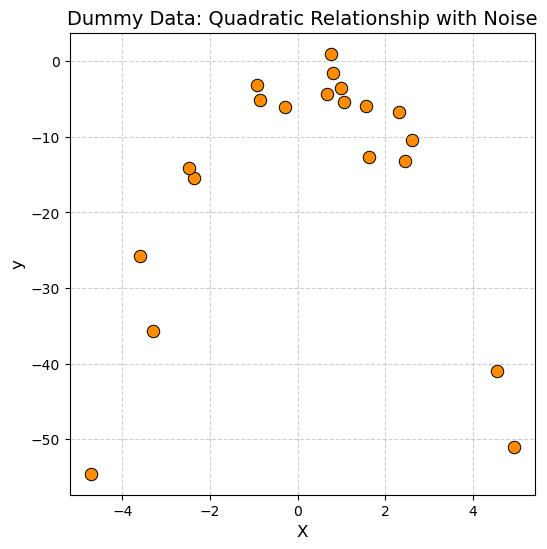

In [47]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)

X = 2 - 3 * np.random.normal(0, 1, 20)

y = X - 2 * (X**2) + np.random.normal(-3, 3, 20)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=X, y=y, color='darkorange', s=80, edgecolor='k')

# Added labels and title
plt.title('Dummy Data: Quadratic Relationship with Noise', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [48]:
X = X.reshape(-1, 1)

degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)


print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred):.2f}")
print(f"R^2 Score: {r2_score(y, y_pred):.2f}")

Coefficients: [ 0.          0.89087515 -2.10967125]
Intercept: -2.08
Mean Squared Error: 11.92
R^2 Score: 0.96


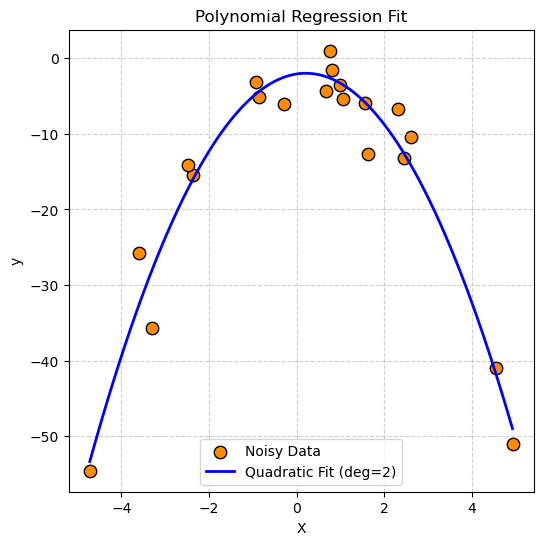

In [56]:
# Create a smooth range of X values for the prediction line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(poly_features.transform(X_line))

plt.figure(figsize=(6, 6))
plt.scatter(X, y, color='darkorange', edgecolor='k', s=80, label='Noisy Data')
plt.plot(X_line, y_line, color='blue', linewidth=2, label=f'Quadratic Fit (deg={degree})')
plt.title('Polynomial Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
